# 1. Wstęp

In [1014]:
import pandas as pd
import sklearn
import keras
import seaborn as sns
import matplotlib.pyplot as plt
import keras_tuner

# 2. Spójrzmy na dane za nim co kolwiek zrobimy

In [1015]:
raw_df = pd.read_csv("dataset.csv", index_col="Unnamed: 0")
raw_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,no,2.2,0,1,no,7,0.6,188,2,...,20,756,2549.0,9,7,19.0,0,0,wifi,medium cost
1,1021,yes,0.5,1,0,yes,53,0.7,136,3,...,905,1988,2631.0,17,3,7.0,1,1,no_wifi,high cost
2,563,yes,0.5,1,2,yes,41,0.9,145,5,...,1263,1716,2603.0,11,2,9.0,1,1,no_wifi,high cost
3,615,yes,2.5,0,0,no,10,0.8,131,6,...,1216,1786,2769.0,16,8,11.0,1,0,no_wifi,high cost
4,1821,yes,1.2,0,13,yes,44,0.6,141,2,...,1208,1212,1411.0,8,2,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,yes,0.5,1,0,yes,2,0.8,106,6,...,1222,1890,668.0,13,4,19.0,1,1,no_wifi,low cost
1996,1965,yes,2.6,1,0,no,39,0.2,187,4,...,915,1965,2032.0,11,10,16.0,1,1,wifi,high cost
1997,1911,no,0.9,1,1,yes,36,0.7,108,8,...,868,1632,3057.0,9,1,5.0,1,1,no_wifi,very high cost
1998,1512,no,0.9,0,4,yes,46,0.1,145,5,...,336,670,869.0,18,10,19.0,1,1,wifi,low cost


In [1016]:
raw_df.describe()

,battery_power,clock_speed,dual_sim,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen
count,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1913.000000,1935.000000,1935.000000,1873.000000,1935.000000,1935.000000
mean,1240.282687,1.528889,0.509044,4.298708,32.115245,0.504703,140.209819,4.529716,9.932817,646.829457,1255.708527,2120.500784,12.322997,5.757623,10.998398,0.762274,0.501809
std,438.590972,0.820332,0.500047,4.345792,18.161480,0.292660,35.480487,2.285474,6.057774,445.042126,434.465962,1083.400626,4.209676,4.333399,5.457734,0.425801,0.500126
min,501.000000,0.500000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000
25%,853.500000,0.700000,0.000000,1.000000,16.000000,0.200000,109.000000,3.000000,5.000000,284.500000,880.000000,1205.000000,9.000000,2.000000,6.000000,1.000000,0.000000
50%,1231.000000,1.500000,1.000000,3.000000,32.000000,0.500000,141.000000,4.000000,10.000000,567.000000,1251.000000,2131.000000,12.000000,5.000000,11.000000,1.000000,1.000000
75%,1617.000000,2.250000,1.000000,7.000000,48.000000,0.800000,170.000000,7.000000,15.000000,948.000000,1638.500000,3056.000000,16.000000,9.000000,16.000000,1.000000,1.000000
max,1998.000000,4.000000,1.000000,19.000000,64.000000,2.000000,200.000000,8.000000,20.000000,1960.000000,2298.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000


Super. Popatrzyliśmy na dane w tabelce.


imo można wywalić pewne kolumny:
- Unnamed: 0 - losowy indeksik, niby można użyć jako key przy wczytaniu
- pc i fc są podobne więc wywaliłbym fc, tak dla beki
- sc_h i sc_w z opisu zbioru są zapisane jako rozmiar ekranu w pikselach, ale dlaczego ich wartości są takie małe?

Zauważamy, że `blue`, `four_g`, `wifi` kodował jakiś humanista i trzeba to przerobić na prawilną binarkę jak w `three_g` `touch_screen`, `dual_sim`

also nie ufałbym wartościom w `m_dep` serio telefon ma 1 mm *grubości* (głębokości)? 

In [1017]:
raw_df = raw_df.drop(columns=["fc", "m_dep", "sc_h", "sc_w"])

In [1018]:
raw_df

,battery_power,blue,clock_speed,dual_sim,four_g,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,talk_time,three_g,touch_screen,wifi,price_range
0,842,no,2.2,0,no,7,188,2,2,20,756,2549.0,19.0,0,0,wifi,medium cost
1,1021,yes,0.5,1,yes,53,136,3,6,905,1988,2631.0,7.0,1,1,no_wifi,high cost
2,563,yes,0.5,1,yes,41,145,5,6,1263,1716,2603.0,9.0,1,1,no_wifi,high cost
3,615,yes,2.5,0,no,10,131,6,9,1216,1786,2769.0,11.0,1,0,no_wifi,high cost
4,1821,yes,1.2,0,yes,44,141,2,14,1208,1212,1411.0,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,yes,0.5,1,yes,2,106,6,14,1222,1890,668.0,19.0,1,1,no_wifi,low cost
1996,1965,yes,2.6,1,no,39,187,4,3,915,1965,2032.0,16.0,1,1,wifi,high cost
1997,1911,no,0.9,1,yes,36,108,8,3,868,1632,3057.0,5.0,1,1,no_wifi,very high cost
1998,1512,no,0.9,0,yes,46,145,5,5,336,670,869.0,19.0,1,1,wifi,low cost


# 3. Preprocessing

In [1019]:
sklearn.set_config(transform_output="pandas")

### 3.1 Preprocessing - Brakujące wartości

In [1020]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1935 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1935 non-null   int64  
 1   blue           1915 non-null   object 
 2   clock_speed    1935 non-null   float64
 3   dual_sim       1935 non-null   int64  
 4   four_g         1935 non-null   object 
 5   int_memory     1935 non-null   int64  
 6   mobile_wt      1935 non-null   int64  
 7   n_cores        1935 non-null   int64  
 8   pc             1935 non-null   int64  
 9   px_height      1935 non-null   int64  
 10  px_width       1935 non-null   int64  
 11  ram            1913 non-null   float64
 12  talk_time      1873 non-null   float64
 13  three_g        1935 non-null   int64  
 14  touch_screen   1935 non-null   int64  
 15  wifi           1935 non-null   object 
 16  price_range    1935 non-null   object 
dtypes: float64(3), int64(10), object(4)
memory usage: 272.1+ 

In [1022]:
df_numeric = raw_df.select_dtypes(include="number")
df_categorical = raw_df.select_dtypes(exclude="number")

from sklearn.impute import SimpleImputer

imputer_numeric = SimpleImputer(strategy='mean')
df_numeric_imputed = imputer_numeric.fit_transform(df_numeric)

imputer_categorical = SimpleImputer(strategy='most_frequent')
df_categorical_imputed = imputer_categorical.fit_transform(df_categorical)

### 3.2 Preprocessing - Dane tekstowe

In [1023]:
df_categorical_imputed

,blue,four_g,wifi,price_range
0,no,no,wifi,medium cost
1,yes,yes,no_wifi,high cost
2,yes,yes,no_wifi,high cost
3,yes,no,no_wifi,high cost
4,yes,yes,no_wifi,medium cost
...,...,...,...,...
1995,yes,yes,no_wifi,low cost
1996,yes,no,wifi,high cost
1997,no,yes,no_wifi,very high cost
1998,no,yes,wifi,low cost


In [1024]:
from sklearn.preprocessing import OneHotEncoder

oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
df_categorical_encoded = oh.fit_transform(df_categorical_imputed)
df_categorical_encoded

,blue_no,blue_yes,four_g_no,four_g_yes,wifi_no_wifi,wifi_wifi,price_range_high cost,price_range_low cost,price_range_medium cost,price_range_very high cost
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1995,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1996,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1997,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1998,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [1025]:
df_transformed = pd.concat([df_numeric_imputed, df_categorical_encoded], axis=1)

X_transformed = df_transformed.drop(columns=["price_range_high cost", "price_range_low cost", "price_range_medium cost", "price_range_very high cost"])
y_transformed = df_transformed[["price_range_high cost", "price_range_low cost", "price_range_medium cost", "price_range_very high cost"]]

X_transformed

,battery_power,clock_speed,dual_sim,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,talk_time,three_g,touch_screen,blue_no,blue_yes,four_g_no,four_g_yes,wifi_no_wifi,wifi_wifi
0,842.0,2.2,0.0,7.0,188.0,2.0,2.0,20.0,756.0,2549.0,19.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,1021.0,0.5,1.0,53.0,136.0,3.0,6.0,905.0,1988.0,2631.0,7.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2,563.0,0.5,1.0,41.0,145.0,5.0,6.0,1263.0,1716.0,2603.0,9.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,615.0,2.5,0.0,10.0,131.0,6.0,9.0,1216.0,1786.0,2769.0,11.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
4,1821.0,1.2,0.0,44.0,141.0,2.0,14.0,1208.0,1212.0,1411.0,15.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794.0,0.5,1.0,2.0,106.0,6.0,14.0,1222.0,1890.0,668.0,19.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
1996,1965.0,2.6,1.0,39.0,187.0,4.0,3.0,915.0,1965.0,2032.0,16.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
1997,1911.0,0.9,1.0,36.0,108.0,8.0,3.0,868.0,1632.0,3057.0,5.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1998,1512.0,0.9,0.0,46.0,145.0,5.0,5.0,336.0,670.0,869.0,19.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0


### 3.3 Preprocessing - Skalowanie
Pamiętajmy, że nie chcemy skalować etykiet i danych zero-jeden, bo skończymy tak:


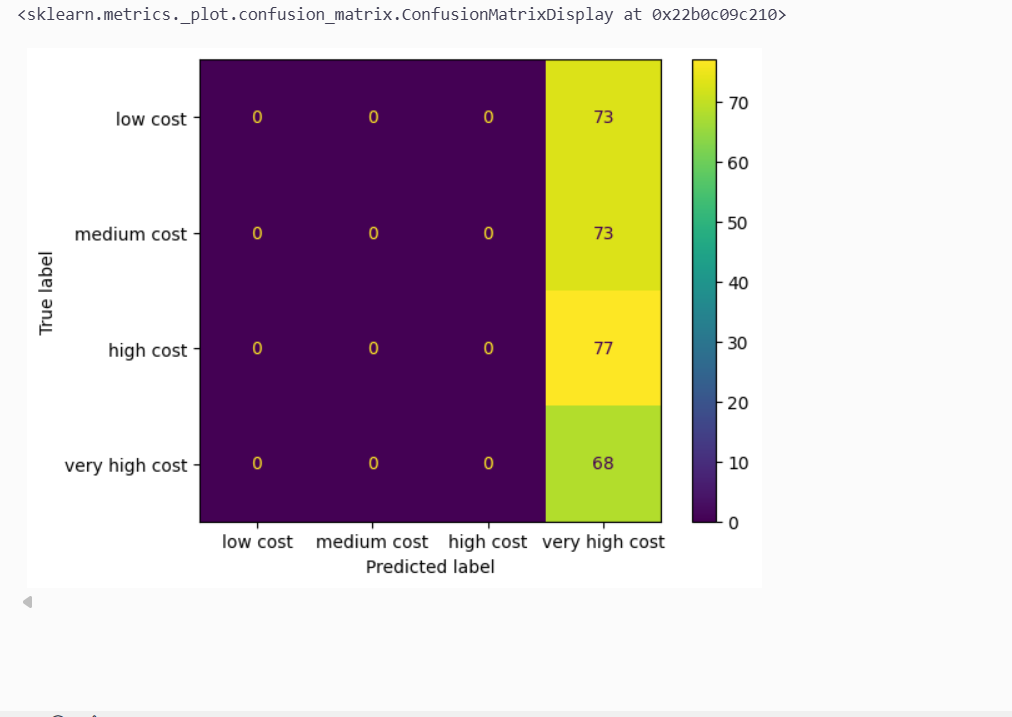

In [1026]:
scaler = sklearn.preprocessing.StandardScaler()

X_to_scale = X_transformed.drop(columns=["dual_sim", "touch_screen", "three_g","blue_no", "blue_yes", "four_g_no", "four_g_yes", "wifi_no_wifi", "wifi_wifi"])
X_scaled = scaler.fit_transform(X_to_scale)

X_final = pd.concat([X_transformed[["dual_sim", "touch_screen", "three_g","blue_no", "blue_yes", "four_g_no", "four_g_yes", "wifi_no_wifi", "wifi_wifi"]], X_scaled], axis=1)

In [1027]:
df_final = pd.concat([X_final, y_transformed], axis=1)
df_final

,dual_sim,touch_screen,three_g,blue_no,blue_yes,four_g_no,four_g_yes,wifi_no_wifi,wifi_wifi,battery_power,...,n_cores,pc,px_height,px_width,ram,talk_time,price_range_high cost,price_range_low cost,price_range_medium cost,price_range_very high cost
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.908331,...,-1.107153,-1.309865,-1.408836,-1.150465,0.397885,1.490569,0.0,0.0,1.0,0.0
1,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,-0.500100,...,-0.669494,-0.649386,0.580254,1.685934,0.474026,-0.744837,1.0,0.0,0.0,0.0
2,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,-1.544623,...,0.205824,-0.649386,1.384880,1.059716,0.448027,-0.372269,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,-1.426031,...,0.643483,-0.154026,1.279244,1.220875,0.602167,0.000298,1.0,0.0,0.0,0.0
4,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.324394,...,-1.107153,0.671573,1.261264,-0.100629,-0.658810,0.745434,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,-1.017800,...,0.643483,0.671573,1.292730,1.460311,-1.348726,1.490569,0.0,1.0,0.0,0.0
1996,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.652803,...,-0.231835,-1.144745,0.602729,1.632981,-0.082178,0.931718,1.0,0.0,0.0,0.0
1997,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.529650,...,1.518801,-1.144745,0.497094,0.866325,0.869591,-1.117405,0.0,0.0,0.0,1.0
1998,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.619683,...,0.205824,-0.814506,-0.698608,-1.348460,-1.162087,1.490569,0.0,1.0,0.0,0.0


# 4. Model

In [1028]:
X = df_final.drop(columns=["price_range_low cost", "price_range_high cost", "price_range_medium cost", "price_range_very high cost"], axis=1)
y = df_final[["price_range_low cost", "price_range_high cost", "price_range_medium cost", "price_range_very high cost"]]

In [1029]:
X_train, X_other, y_train, y_other = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = sklearn.model_selection.train_test_split(X_other, y_other, test_size=0.5, random_state=42)

In [1030]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(4, activation='softmax'),
])

In [1031]:
def display_history(history):
    sns.lineplot(history.history)
    plt.grid()
    plt.xlabel("Epoch")
    plt.ylabel("Value")

In [1032]:
initial_weights = model.get_weights()

**categorical_crossentropy**:
- Mam 4 etykiety 
- Używam softmaxa bo chce mieć 0 i 1 jako predykcje
- Moje etykiety to OH encoded wektor dlatego CCE.

Gdybym obliczał strate według pojedyńczego indeksu (np. 1 dla medium cost) a nie wektora [0,1,0,0] użył bym *Sparse Categorical Cross-Entropy*

In [1033]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.set_weights(initial_weights)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5148 - loss: 1.0864 - val_accuracy: 0.7483 - val_loss: 0.6890 - learning_rate: 0.0100
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8685 - loss: 0.4694 - val_accuracy: 0.8655 - val_loss: 0.4518 - learning_rate: 0.0100
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9077 - loss: 0.2959 - val_accuracy: 0.8862 - val_loss: 0.3700 - learning_rate: 0.0100
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9195 - loss: 0.2453 - val_accuracy: 0.8966 - val_loss: 0.3559 - learning_rate: 0.0100
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9306 - loss: 0.2029 - val_accuracy: 0.8897 - val_loss: 0.3526 - learning_rate: 0.0100
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9313 - loss: 0.1933 - val_accuracy: 0.9138 - val_loss: 0.3289 - learning_rate: 0.0100
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9372 - loss: 0.1825 - val_acc

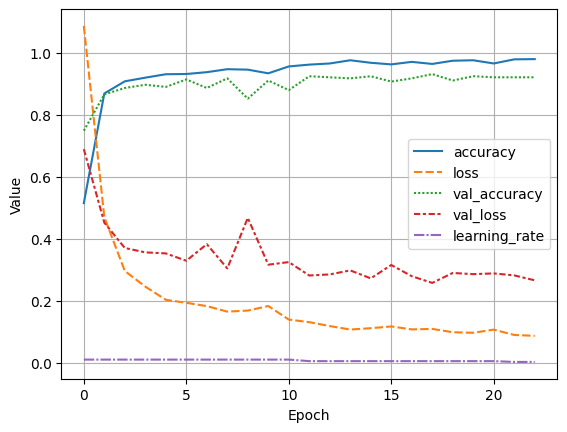

In [1034]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
)

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[early_stopping, reduce_lr], verbose=1)
display_history(history)   

In [1035]:
mean_absolute_error = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"MAE - test set: {mean_absolute_error}")


mean_absolute_error = model.evaluate(X_valid, y_valid, verbose=0)[1]
print(f"MAE - valid set: {mean_absolute_error}")

MAE - test set: 0.9793814420700073
MAE - valid set: 0.9206896424293518


In [1036]:
model_predictions = model.predict(X_test)
model_predictions

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[3.48427572e-11, 8.75469239e-04, 7.73520128e-08, 9.99124467e-01],
       [1.19161465e-04, 9.41496670e-01, 4.27606255e-02, 1.56235574e-02],
       [3.41992234e-07, 9.97992992e-01, 1.34982591e-04, 1.87171251e-03],
       ...,
       [1.82601555e-11, 4.88644117e-04, 4.60616931e-08, 9.99511361e-01],
       [5.00766607e-03, 7.53309950e-02, 9.06455755e-01, 1.32056801e-02],
       [1.33058807e-11, 3.66915076e-04, 3.38420456e-08, 9.99633074e-01]],
      shape=(291, 4), dtype=float32)

# 5. Ocena predykcji

### 5.1 Accuracy

In [1037]:
sklearn.metrics.accuracy_score(model_predictions.argmax(axis=1), y_test.values.argmax(axis=1))

0.979381443298969

### 5.2 Confusion Matrix


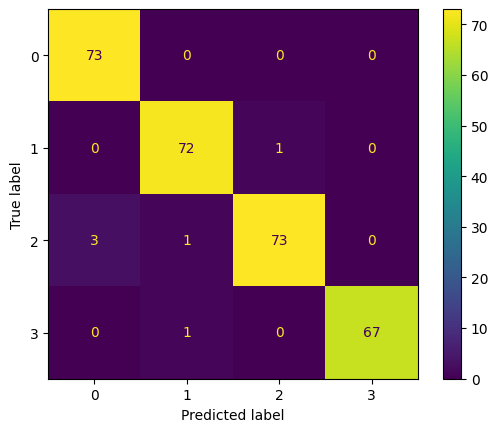

In [1038]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test.values.argmax(axis=1), model_predictions.argmax(axis=1))

### 5.3 Precision, Recall, F1

In [1039]:
print(sklearn.metrics.classification_report(y_test.values.argmax(axis=1), model_predictions.argmax(axis=1), target_names=["low cost", "medium cost", "high cost", "very high cost"]))

                precision    recall  f1-score   support

      low cost       0.96      1.00      0.98        73
   medium cost       0.97      0.99      0.98        73
     high cost       0.99      0.95      0.97        77
very high cost       1.00      0.99      0.99        68

      accuracy                           0.98       291
     macro avg       0.98      0.98      0.98       291
  weighted avg       0.98      0.98      0.98       291



### 5.4 Sprawdzenie overfittingu
Generalnie przyjmuje, że jeśli accuracy $Train \gg Test$  to jest overfitting ( $\gg$ - znacznie większe)

In [1040]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Valid Accuracy: {valid_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Train Accuracy: 0.9823
Valid Accuracy: 0.9207
Test Accuracy: 0.9794
